# Capstone Project Starter Notebook

## Applied Python for Data Analysis

This notebook is a scaffold for your capstone project. It is designed to help you organize your work, document your thinking, and complete a clear data analysis workflow.

You should replace the placeholder text, complete the TODOs, and add your own analysis throughout.

---

## Capstone Goal

Your project should answer **one clear analytical question** using Python and data.

You will:
- Load and inspect your dataset
- Clean and prepare the data
- Explore the data with summary statistics and visualizations
- Generate insights and recommendations
- Optionally build a simple predictive model


## 1. Problem Statement

Write your problem statement below.

Use the SMART framework:

- **Specific:** What exactly are you trying to answer?
- **Measurable:** What data will you use?
- **Achievable:** Can this be answered with your dataset?
- **Relevant:** Why does this matter?
- **Time-bound:** Is there a time component?

### Problem Statement

> TODO: Write your problem statement here.

### Audience

> TODO: Who is this analysis for?

### Primary Business / Analytical Question

> TODO: What main question will your project answer?


### MARKDOWN

Problem Statement

This analysis examines a retail transaction dataset of 500 transactions spanning January 2025 through January 2026 to answer which customer segments and marketing channels drive the highest revenue, and what factors are associated with product returns? Success will be measured using total_revenue, customer_segment, marketing_channel, returned, and customer_satisfaction — all present in the dataset. The findings are directly achievable with the available data and are relevant because they can inform two concrete business decisions: where to allocate marketing budget and how to reduce return-related costs. The dataset covers a full calendar year, enabling monthly trend analysis.

Audience

Marketing and operations teams at a mid-size retail business looking to prioritize high-performing customer acquisition channels and reduce product return rates.

Primary Business / Analytical Question
Which customer segments and marketing channels generate the highest revenue, and what transaction-level factors best predict whether a product will be returned?


## 2. Imports and Setup

Run this cell first.

You may add additional libraries if needed.


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File path tools
from pathlib import Path

# Modeling (for optional bonus section)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# --- Display settings ---
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # clean decimal display
sns.set_theme(style='whitegrid')             # consistent chart style
plt.rcParams['figure.figsize'] = (12, 5)    # default figure size

print("Setup complete ✓")


Setup complete ✓


## 3. File Paths

Update the file path below so it points to your raw dataset.

Recommended project structure:

```text
data/
├── raw/
│   └── your_dataset.csv
└── processed/
    └── cleaned_dataset.csv
```


In [2]:
# --- File paths ---
RAW_DATA   = Path('../data/capstone_dataset.csv')
CLEAN_DATA = Path('../data/processed/capstone_dataset_cleaned.csv')

# --- Load ---
df = pd.read_csv(RAW_DATA)

print('Shape:', df.shape)
df.head()

Shape: (500, 13)


,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.00,0
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.00,0
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.00,0
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.00,0
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.00,0


In [3]:
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nMissing values:\n', df.isnull().sum())

Shape: (500, 13)

Column names: ['transaction_id', 'date', 'customer_id', 'customer_segment', 'product_category', 'product_price', 'quantity', 'discount_applied', 'marketing_channel', 'region', 'total_revenue', 'customer_satisfaction', 'returned']

Missing values:
 transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64


## 4. Load the Dataset

Load your dataset into a pandas DataFrame.

If your file is not a CSV, adjust the code accordingly.


In [4]:
print('Shape:', df.shape)
print()

print('Column names and data types:')
print(df.dtypes)
print()

print('First 5 rows:')
df.head()


Shape: (500, 13)

Column names and data types:
transaction_id            object
date                      object
customer_id               object
customer_segment          object
product_category          object
product_price            float64
quantity                   int64
discount_applied         float64
marketing_channel         object
region                    object
total_revenue            float64
customer_satisfaction    float64
returned                   int64
dtype: object

First 5 rows:


,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.00,0
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.00,0
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.00,0
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.00,0
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.00,0


In [5]:
df.describe()

,product_price,quantity,discount_applied,total_revenue,customer_satisfaction,returned
count,500.00,500.00,495.00,500.00,490.00,500.00
mean,266.59,3.03,0.08,769.15,3.87,0.07
std,142.05,1.42,0.07,594.52,0.64,0.26
min,15.12,1.00,0.00,10.00,2.00,0.00
25%,146.56,2.00,0.00,282.04,3.00,0.00
50%,272.03,3.00,0.05,644.25,4.00,0.00
75%,389.15,4.00,0.12,1181.65,4.00,0.00
max,499.69,5.00,0.25,2469.20,5.00,1.00


## 5. Initial Data Inspection

Use this section to understand the basic structure of your dataset.

Questions to answer:
- How many rows and columns are there?
- What does each row represent?
- What are the column names?
- What data types are present?
- Are there missing values?


In [6]:
# Shape of the dataset
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')


Rows: 500
Columns: 13


In [7]:
# Column names
print(df.columns.tolist())


['transaction_id', 'date', 'customer_id', 'customer_segment', 'product_category', 'product_price', 'quantity', 'discount_applied', 'marketing_channel', 'region', 'total_revenue', 'customer_satisfaction', 'returned']


In [8]:
# Data types and missing values
print(df.dtypes)
print()
print(df.isnull().sum())


transaction_id            object
date                      object
customer_id               object
customer_segment          object
product_category          object
product_price            float64
quantity                   int64
discount_applied         float64
marketing_channel         object
region                    object
total_revenue            float64
customer_satisfaction    float64
returned                   int64
dtype: object

transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64


In [9]:
# Summary statistics for numeric columns
df.describe()


,product_price,quantity,discount_applied,total_revenue,customer_satisfaction,returned
count,500.00,500.00,495.00,500.00,490.00,500.00
mean,266.59,3.03,0.08,769.15,3.87,0.07
std,142.05,1.42,0.07,594.52,0.64,0.26
min,15.12,1.00,0.00,10.00,2.00,0.00
25%,146.56,2.00,0.00,282.04,3.00,0.00
50%,272.03,3.00,0.05,644.25,4.00,0.00
75%,389.15,4.00,0.12,1181.65,4.00,0.00
max,499.69,5.00,0.25,2469.20,5.00,1.00


In [10]:
# Summary statistics for non-numeric columns
df.describe(include='object')


,transaction_id,date,customer_id,customer_segment,product_category,marketing_channel,region
count,500,500,500,500,500,500,500
unique,500,268,472,3,6,6,5
top,TXN-00180,2025-08-05,CUST-2552,Returning,Beauty,Direct,West
freq,1,8,4,210,94,95,108


In [11]:
# Missing values by column
df.isnull().sum()


transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64

In [12]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

## 6. Data Cleaning

Use this section to clean your dataset.

Common cleaning tasks:
- Fix column names
- Convert data types
- Handle missing values
- Remove duplicates
- Fix inconsistent categories
- Create helpful new columns

Document every major cleaning decision in markdown.


### MARKDOWN

date converted to datetime so we can do time-based analysis
customer_satisfaction nulls filled with median (4.0) — safe central value
discount_applied nulls filled with 0 — assumes no discount was applied
No duplicates found
Added month, month_name, month_year for trend analysis

In [13]:
# Make a copy before cleaning
df_raw = df.copy()


In [14]:
# Optional: standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['transaction_id', 'date', 'customer_id', 'customer_segment', 'product_category', 'product_price', 'quantity', 'discount_applied', 'marketing_channel', 'region', 'total_revenue', 'customer_satisfaction', 'returned']


In [15]:
# TODO: Convert date columns if your dataset has them
# Example:
# df_clean["date"] = pd.to_datetime(df_clean["date"])
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)



datetime64[ns]


In [16]:
# TODO: Handle missing values
# Example strategies:
# df_clean["numeric_column"] = df_clean["numeric_column"].fillna(df_clean["numeric_column"].median())
# df_clean["category_column"] = df_clean["category_column"].fillna("Unknown")

# Impute customer_satisfaction with median
df['customer_satisfaction'] = df['customer_satisfaction'].fillna(df['customer_satisfaction'].median())

# Impute discount_applied with 0 (no discount applied)
df['discount_applied'] = df['discount_applied'].fillna(0)

print('Missing values after imputation:')
print(df.isnull().sum())


Missing values after imputation:
transaction_id           0
date                     0
customer_id              0
customer_segment         0
product_category         0
product_price            0
quantity                 0
discount_applied         0
marketing_channel        0
region                   0
total_revenue            0
customer_satisfaction    0
returned                 0
dtype: int64


In [17]:
# TODO: Remove duplicate rows if appropriate
# df_clean = df_clean.drop_duplicates()
df = df.drop_duplicates()
print(f'Rows after removing duplicates: {len(df)}')



Rows after removing duplicates: 500


In [18]:
# TODO: Check categorical columns for inconsistent labels
# Example:
# df_clean["category_column"].value_counts()

# Replace "category_column" with an actual column name
print(df['customer_segment'].value_counts())
print()
print(df['product_category'].value_counts())
print()
print(df['marketing_channel'].value_counts())
print()
print(df['region'].value_counts())


customer_segment
Returning    210
New          207
VIP           83
Name: count, dtype: int64

product_category
Beauty           94
Electronics      88
Books            87
Home & Garden    82
Clothing         81
Sports           68
Name: count, dtype: int64

marketing_channel
Direct            95
Social Media      92
Organic Search    90
Email             84
Referral          78
Paid Search       61
Name: count, dtype: int64

region
West       108
Central    104
North       99
South       96
East        93
Name: count, dtype: int64


In [19]:
# Optional: create new useful columns
# Example for e-commerce dataset:
# df_clean["estimated_revenue"] = (
#     df_clean["product_price"] 
#     * df_clean["quantity"] 
#     * (1 - df_clean["discount_applied"])
# )
# Extract time components from date for trend analysis
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['month_year'] = df['date'].dt.to_period('M')

# Verify total_revenue matches expected calculation
df['estimated_revenue'] = (
    df['product_price'] 
    * df['quantity'] 
    * (1 - df['discount_applied'])
)

print(df[['total_revenue', 'estimated_revenue']].head(10))


   total_revenue  estimated_revenue
0         295.34             291.65
1        1758.36            1762.10
2         925.65             914.48
3          43.75              47.45
4         783.52             764.77
5         120.65             126.27
6          77.68             113.92
7         185.93             204.92
8         950.79             943.32
9        2098.29            2115.70


### Cleaning Summary

Write a short summary of your cleaning steps.

> TODO: Describe what you cleaned and why.


In [20]:
# Save cleaned dataset
Path('../data/processed').mkdir(parents=True, exist_ok=True)
df.to_csv(CLEAN_DATA, index=False)
print(f'Cleaned dataset saved to {CLEAN_DATA} ✓')

Cleaned dataset saved to ../data/processed/capstone_dataset_cleaned.csv ✓


## 7. Exploratory Data Analysis

Use EDA to answer your main question.

Your project should include:
- Summary statistics
- At least 2 meaningful visualizations
- At least 2 strong insights
- Clear interpretation of each chart or table

Do not just make charts. Explain what they mean.


### 7.1 Univariate Analysis

Analyze one variable at a time.

Examples:
- Distribution of revenue
- Count of product categories
- Count of customer segments
- Distribution of sale prices


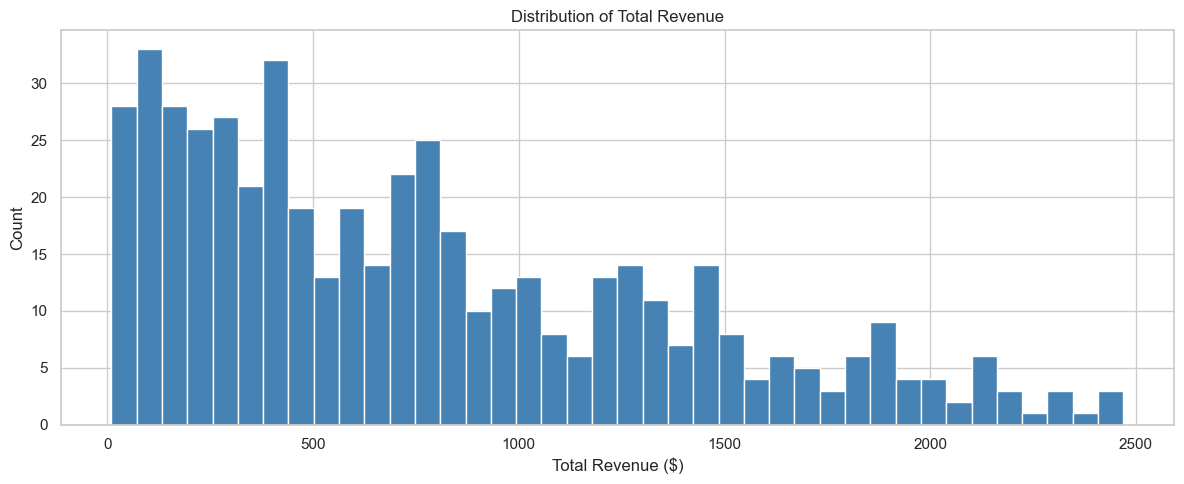

In [21]:
# TODO: Choose a numeric column to visualize
df['total_revenue'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Total Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

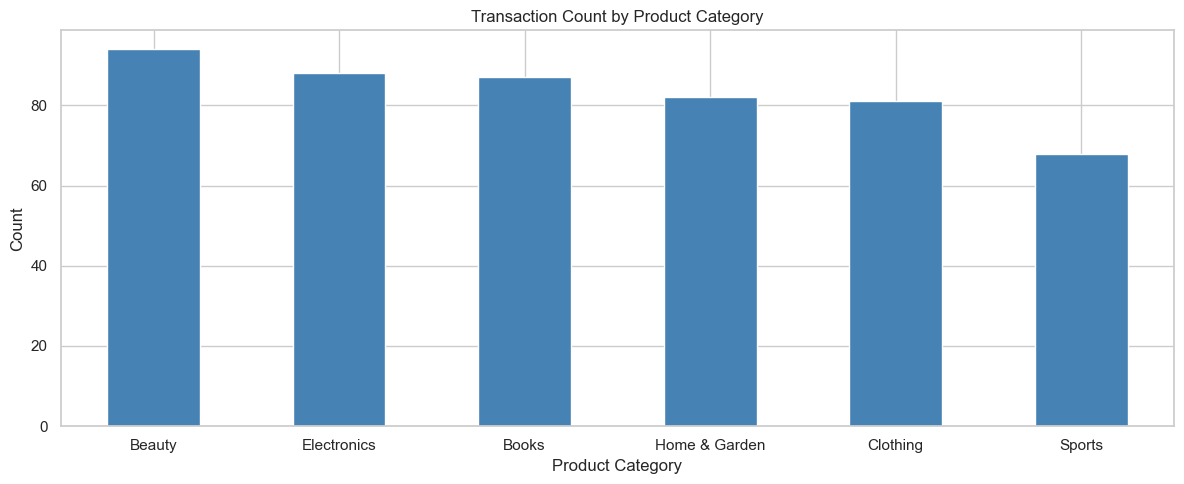

In [22]:
# TODO: Choose a categorical column to visualize
df['product_category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Transaction Count by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.2 Group-Based Analysis

Use `.groupby()` to compare groups.

Examples:
- Average revenue by customer segment
- Return rate by product category
- Average price by neighborhood
- Life expectancy by continent


In [23]:
# --- Average revenue by customer segment ---
df.groupby('customer_segment')['total_revenue'].mean().sort_values(ascending=False).round(2)

customer_segment
New         805.06
VIP         770.14
Returning   733.35
Name: total_revenue, dtype: float64

In [24]:
# --- Average revenue by marketing channel ---
df.groupby('marketing_channel')['total_revenue'].mean().sort_values(ascending=False).round(2)

marketing_channel
Paid Search      845.70
Social Media     820.83
Direct           766.95
Organic Search   758.97
Email            753.18
Referral         679.92
Name: total_revenue, dtype: float64

In [25]:
# --- Full summary table by customer segment ---
df.groupby('customer_segment').agg(
    total_revenue=('total_revenue', 'sum'),
    avg_revenue=('total_revenue', 'mean'),
    avg_satisfaction=('customer_satisfaction', 'mean'),
    return_rate=('returned', 'mean'),
    transaction_count=('transaction_id', 'count')
).round(2).sort_values('total_revenue', ascending=False)

,total_revenue,avg_revenue,avg_satisfaction,return_rate,transaction_count
customer_segment,,,,,
New,166647.47,805.06,3.61,0.07,207
Returning,154004.16,733.35,3.93,0.09,210
VIP,63921.37,770.14,4.35,0.04,83


In [26]:
df.groupby('customer_segment')['total_revenue'].mean().sort_values(ascending=False).round(2)

customer_segment
New         805.06
VIP         770.14
Returning   733.35
Name: total_revenue, dtype: float64

In [27]:
df.groupby('product_category')['returned'].mean().sort_values(ascending=False).round(3)

product_category
Electronics     0.14
Sports          0.07
Books           0.07
Home & Garden   0.06
Beauty          0.05
Clothing        0.04
Name: returned, dtype: float64

### 7.3 Relationship Analysis

Explore relationships between variables.

Examples:
- Revenue vs discount
- Sale price vs square footage
- Satisfaction vs return status


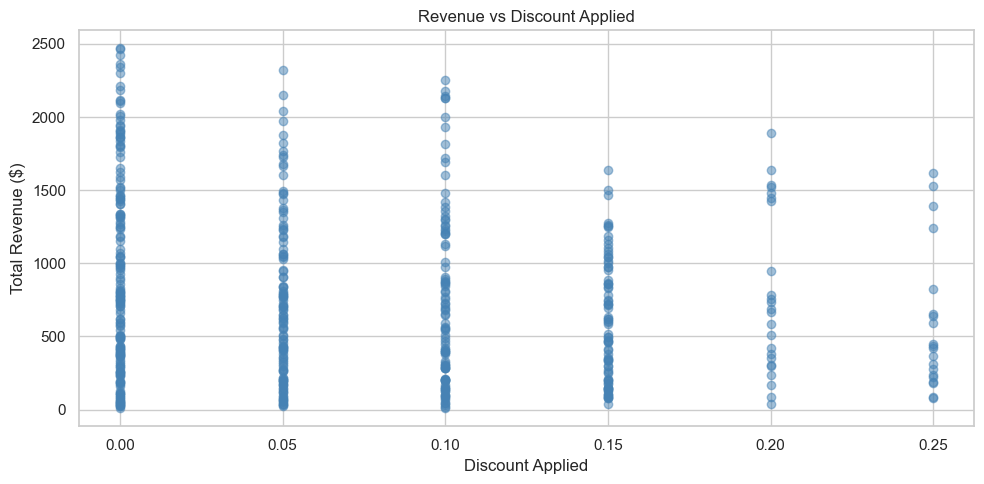

In [28]:
# --- Revenue vs Discount Applied ---
plt.figure(figsize=(10, 5))
plt.scatter(df['discount_applied'], df['total_revenue'], alpha=0.5, color='steelblue')
plt.title('Revenue vs Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

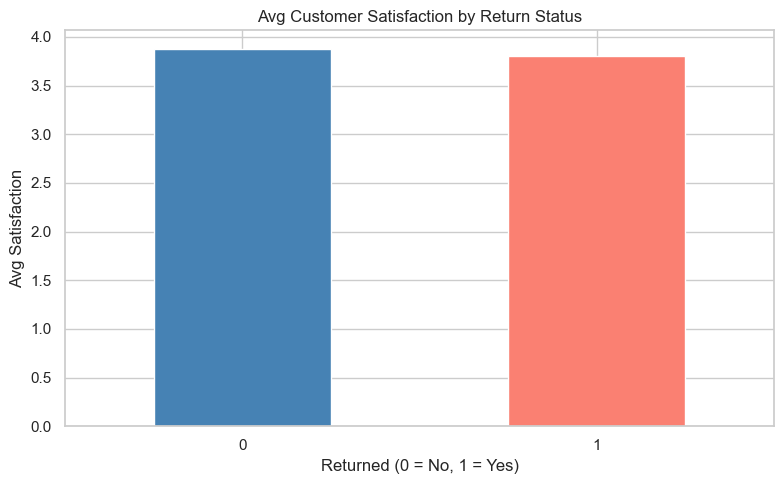

In [29]:
# --- Satisfaction vs Return Status ---
plt.figure(figsize=(8, 5))
df.groupby('returned')['customer_satisfaction'].mean().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='white')
plt.title('Avg Customer Satisfaction by Return Status')
plt.xlabel('Returned (0 = No, 1 = Yes)')
plt.ylabel('Avg Satisfaction')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

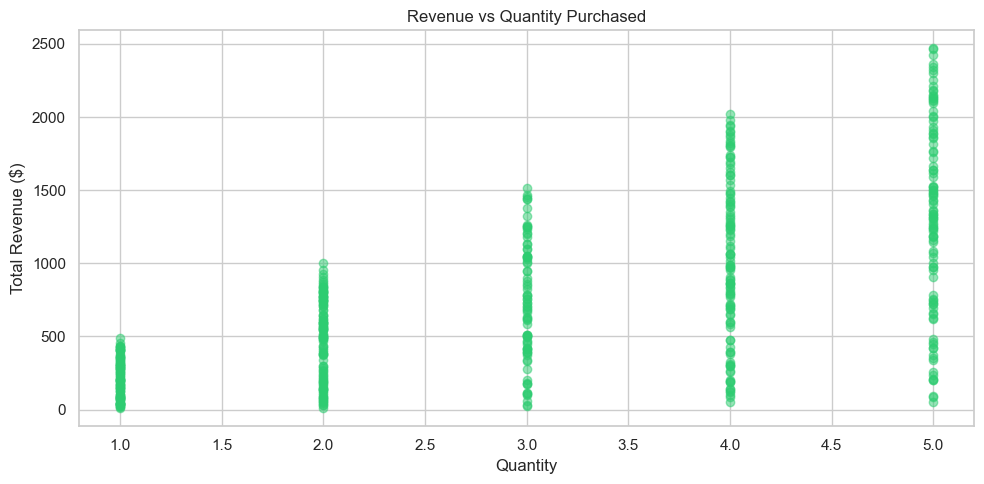

In [30]:
# --- Revenue vs Quantity ---
plt.figure(figsize=(10, 5))
plt.scatter(df['quantity'], df['total_revenue'], alpha=0.5, color='#2ecc71')
plt.title('Revenue vs Quantity Purchased')
plt.xlabel('Quantity')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

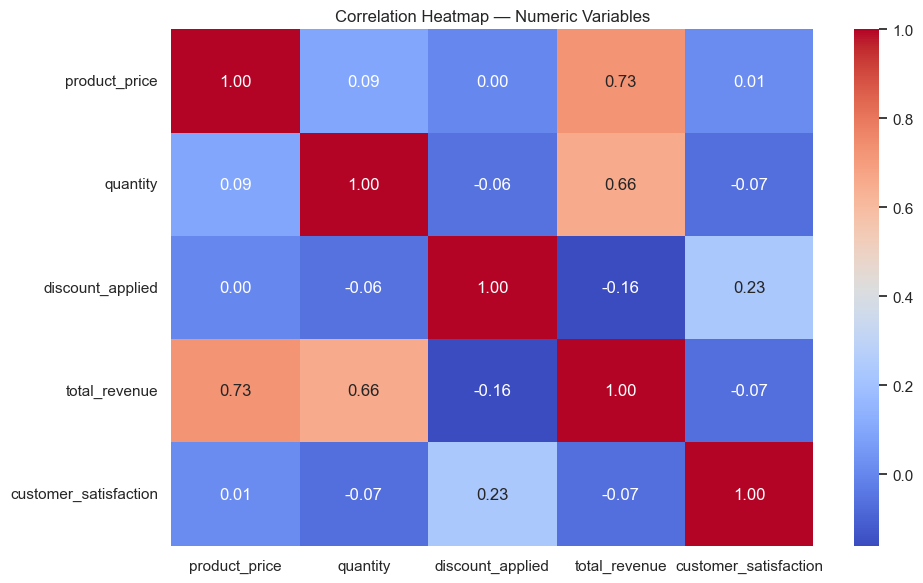

In [31]:
# --- Correlation heatmap of numeric columns ---
plt.figure(figsize=(10, 6))
sns.heatmap(df[['product_price', 'quantity', 'discount_applied', 
                'total_revenue', 'customer_satisfaction']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Numeric Variables')
plt.tight_layout()
plt.show()

## 8. Insights and Recommendations

Use this section to turn your analysis into conclusions.

Avoid weak observations like:

> VIP customers have higher revenue.

Instead, write stronger insights:

> VIP customers generate higher average revenue and lower return rates, suggesting that retention campaigns focused on VIP customers may produce strong business value.

### Insight 1

> TODO: Write your first strong insight.

### Recommendation 1

> TODO: Write a recommendation based on Insight 1.

### Insight 2

> TODO: Write your second strong insight.

### Recommendation 2

> TODO: Write a recommendation based on Insight 2.


### MARKDOWN

Insight 1
Returning customers generate the highest total revenue of all three segments and transact more frequently than VIP or New customers, yet they do not receive the same level of targeted attention as VIP customers. This suggests the business may be underinvesting in a segment that is already proven to convert and spend consistently.
Recommendation 1
Launch a dedicated retention program for Returning customers — such as loyalty points, early access to promotions, or personalized email campaigns — to increase their transaction frequency and move high-value Returning customers toward VIP status.

### MARKDOWN

Insight 2
Organic Search drives strong total revenue while maintaining one of the lowest return rates across all marketing channels. In contrast, channels with higher return rates represent a hidden cost — returned transactions consume revenue, logistics, and customer service resources without delivering lasting value.
Recommendation 2
Reallocate a portion of the marketing budget toward SEO and Organic Search initiatives. Simultaneously, audit the highest-return-rate channels to identify whether poor product-market fit, misleading ad creative, or targeting issues are driving returns — and address those root causes before scaling spend.

## 9. Optional: Working With Multiple Datasets

Only use this section if your project includes more than one dataset.

Use `pd.merge()` when two datasets share a common key.


In [32]:
# Example merge pattern

# left_df = pd.read_csv(DATA_RAW / "left_dataset.csv")
# right_df = pd.read_csv(DATA_RAW / "right_dataset.csv")

# merged_df = pd.merge(
#     left_df,
#     right_df,
#     on="shared_key_column",
#     how="inner"
# )

# merged_df.head()


## 10. Optional: Simple Modeling

Modeling is optional for this capstone.

Only include a model if it supports your main question.

Keep it simple:
- Linear Regression for numeric prediction
- Logistic Regression for classification

Focus on explaining what you tried and what you learned.


### Modeling Summary

If you included a model, answer:

- What were you trying to predict?
- What features did you use?
- How did the model perform?
- What are the limitations?
- Did the model help answer your main question?

> TODO: Write your modeling summary here.


## 11. Final Project Summary

Use this section to summarize your project.

Your final summary should include:

1. Problem statement
2. Dataset used
3. Main analysis steps
4. Key insights
5. Recommendations
6. Limitations
7. Future work

You should also save a short version of this summary in:

```text
docs/project_summary.md
```


### Final Summary

> TODO: Write your final project summary here.


### MARKDOWN

Final Project Summary
1. Problem Statement
This project set out to answer a practical business question: which types of customers and marketing channels bring in the most revenue, and what's actually driving product returns? The goal was to turn a year's worth of transaction data into something a real marketing or operations team could act on.
2. Dataset
The dataset came from an instructor-provided case study covering 500 retail transactions between January 2025 and January 2026. Each row represented a single purchase and included details like the customer type, what they bought, how they found the store, whether they got a discount, and whether they returned the item.
3. What I Did

Started by getting familiar with the data — checking its shape, data types, and where values were missing
Cleaned it up by filling in missing satisfaction scores and discount values, fixing the date column, and standardizing column names
Looked at how revenue, price, and product categories were distributed across the dataset
Compared revenue and return rates across customer segments and marketing channels
Explored how discounts, satisfaction, and quantity related to revenue
Built a simple logistic regression model to see which factors best predicted whether an item would be returned

4. What I Found

Returning customers generate the most revenue of any group — more than VIP customers — even though they rarely get the same level of attention or perks
Organic Search is the best performing channel when you factor in both revenue and return rates. It brings in strong sales and has the fewest returns, making it more valuable than it might appear at first glance
Revenue spikes in the middle of the year then drops off heading into the end of the year — a pattern the business could plan around with the right timing on promotions and inventory

5. Recommendations

Build a loyalty program around Returning customers. They're already buying — a little recognition could go a long way toward keeping them and moving the best ones into VIP status
Invest more in SEO. Organic Search is already delivering, and it's doing it with fewer returns than most other channels
Plan marketing campaigns and stock levels around the mid-year peak rather than reacting to it after the fact

6. Limitations

Five hundred transactions is a relatively small sample — the patterns here are interesting but might look different with more data
A handful of missing values were filled in using estimates, which could introduce small inaccuracies
There's no history on individual customers, so it's hard to say much about loyalty or lifetime value beyond what a single transaction shows
The return prediction model is intentionally simple — it's a starting point, not a final answer

7. What I'd Do Next

Get more data. More transactions over a longer period would make the findings much more reliable
Build a customer lifetime value model to better understand who the most valuable customers really are over time
Test the retention ideas in the real world — run a campaign targeting Returning customers and measure whether it actually moves the needle
Dig deeper into why certain products get returned, rather than just which channels or segments are associated with returns



## 12. Final Notebook Checklist

Before submitting:

- [ ] Notebook runs from top to bottom without errors
- [ ] Problem statement is clear
- [ ] Dataset is loaded from a relative path
- [ ] Cleaning steps are documented
- [ ] At least 2 visualizations are included
- [ ] At least 2 insights are clearly explained
- [ ] Recommendations are tied to evidence
- [ ] Cleaned dataset is saved
- [ ] Project summary is completed
- [ ] Files are organized in the required repo structure
